In [75]:
import pandas as pd
import numpy as np

In [76]:
df = pd.read_csv("C:\\Users\\shivam giri\\OneDrive\\Desktop\\Customer_churn_Analysis.csv")
df

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,43397-UTT,Female,41,No,Uttar Pradesh,6,33,NaN,Yes,Yes,...,Credit Card,74.40,896.75,0.00,0,37.96,934.71,Churned,Competitor,Competitor made better offer
6414,22240-HAR,Male,51,Yes,Haryana,0,19,Deal 1,No,NaN,...,Credit Card,45.25,3139.80,0.00,0,0.00,3139.80,Stayed,NaN,NaN
6415,78682-KER,Female,65,Yes,Kerala,14,25,NaN,Yes,Yes,...,Bank Withdrawal,74.95,2869.85,0.00,0,599.64,3469.49,Churned,Dissatisfaction,Product dissatisfaction
6416,17816-ODI,Male,23,No,Odisha,2,10,NaN,Yes,Yes,...,Credit Card,70.15,4480.70,0.00,0,2107.52,6588.22,Stayed,NaN,NaN


In [77]:
#DATA CLEANING AND DATA INFOR

In [78]:
df.shape

(6418, 32)

In [79]:
# Rows 6418 and columns 32

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [81]:
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [82]:
df.isnull().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3548
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                1390
Online_Backup                  1390
Device_Protection_Plan         1390
Premium_Support                1390
Streaming_TV                   1390
Streaming_Movies               1390
Streaming_Music                1390
Unlimited_Data                 1390
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [83]:
#Numerical_num
num_col = [col for col in df.columns if df[col].dtype!="object"]
num_col

['Age',
 'Number_of_Referrals',
 'Tenure_in_Months',
 'Monthly_Charge',
 'Total_Charges',
 'Total_Refunds',
 'Total_Extra_Data_Charges',
 'Total_Long_Distance_Charges',
 'Total_Revenue']

In [84]:
# categorical_columns
cat_col = [col for col in df.columns if df[col].dtypes=="object"]
cat_col


['Customer_ID',
 'Gender',
 'Married',
 'State',
 'Value_Deal',
 'Phone_Service',
 'Multiple_Lines',
 'Internet_Service',
 'Internet_Type',
 'Online_Security',
 'Online_Backup',
 'Device_Protection_Plan',
 'Premium_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Streaming_Music',
 'Unlimited_Data',
 'Contract',
 'Paperless_Billing',
 'Payment_Method',
 'Customer_Status',
 'Churn_Category',
 'Churn_Reason']

In [85]:
df

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,43397-UTT,Female,41,No,Uttar Pradesh,6,33,NaN,Yes,Yes,...,Credit Card,74.40,896.75,0.00,0,37.96,934.71,Churned,Competitor,Competitor made better offer
6414,22240-HAR,Male,51,Yes,Haryana,0,19,Deal 1,No,NaN,...,Credit Card,45.25,3139.80,0.00,0,0.00,3139.80,Stayed,NaN,NaN
6415,78682-KER,Female,65,Yes,Kerala,14,25,NaN,Yes,Yes,...,Bank Withdrawal,74.95,2869.85,0.00,0,599.64,3469.49,Churned,Dissatisfaction,Product dissatisfaction
6416,17816-ODI,Male,23,No,Odisha,2,10,NaN,Yes,Yes,...,Credit Card,70.15,4480.70,0.00,0,2107.52,6588.22,Stayed,NaN,NaN


In [86]:
num_cols = df.select_dtypes(exclude='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Values filled with median")

Values filled with median


In [87]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

print("Categorical values filled with 'Unknown'")

Categorical values filled with 'Unknown'


In [88]:
df.isnull().sum()

Customer_ID                    0
Gender                         0
Age                            0
Married                        0
State                          0
Number_of_Referrals            0
Tenure_in_Months               0
Value_Deal                     0
Phone_Service                  0
Multiple_Lines                 0
Internet_Service               0
Internet_Type                  0
Online_Security                0
Online_Backup                  0
Device_Protection_Plan         0
Premium_Support                0
Streaming_TV                   0
Streaming_Movies               0
Streaming_Music                0
Unlimited_Data                 0
Contract                       0
Paperless_Billing              0
Payment_Method                 0
Monthly_Charge                 0
Total_Charges                  0
Total_Refunds                  0
Total_Extra_Data_Charges       0
Total_Long_Distance_Charges    0
Total_Revenue                  0
Customer_Status                0
Churn_Cate

In [89]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns

    

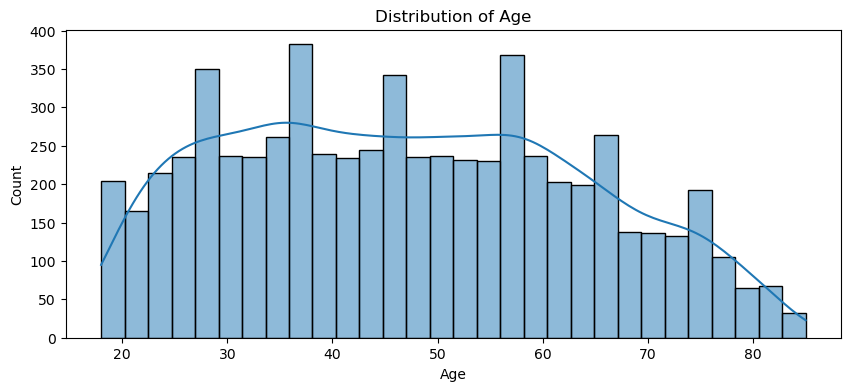

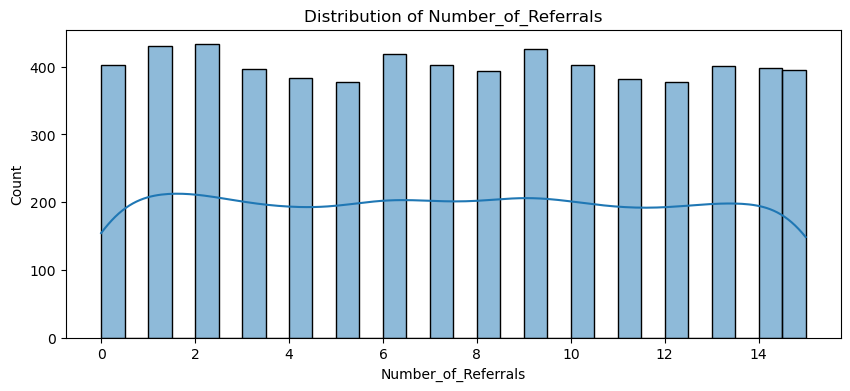

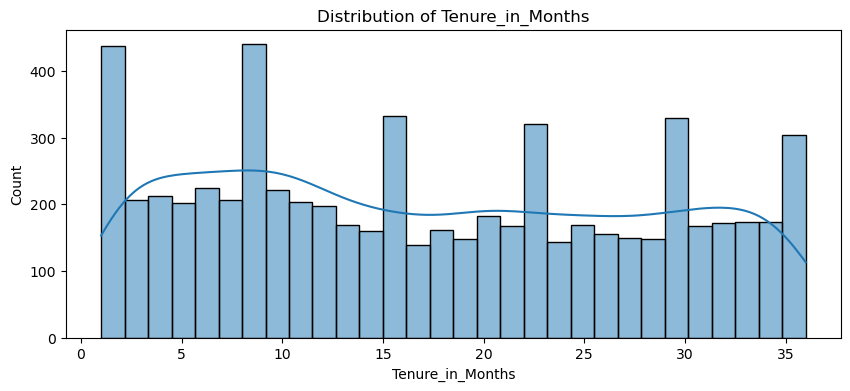

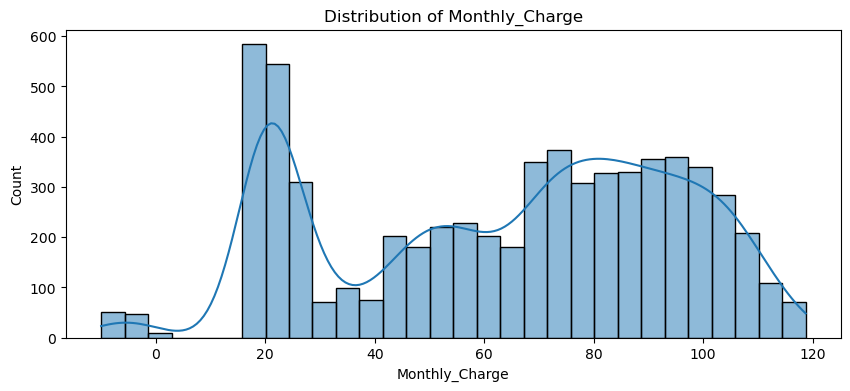

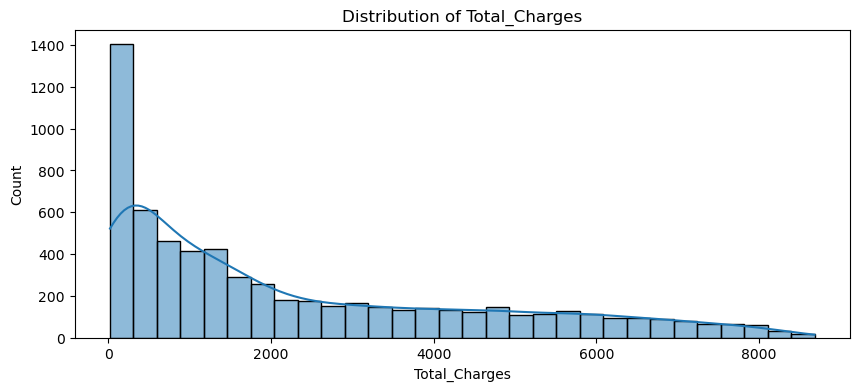

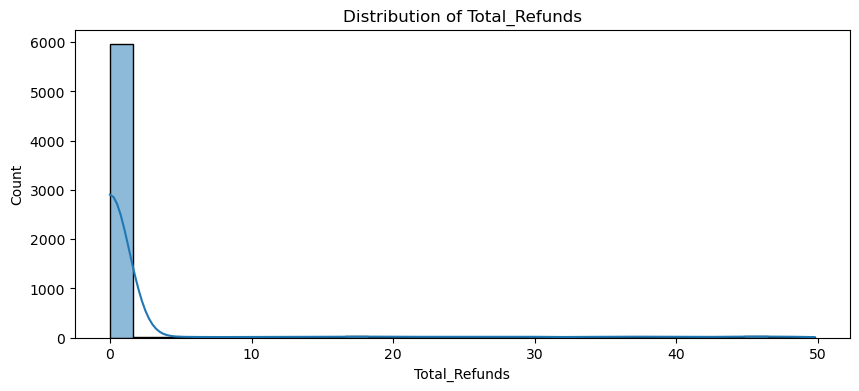

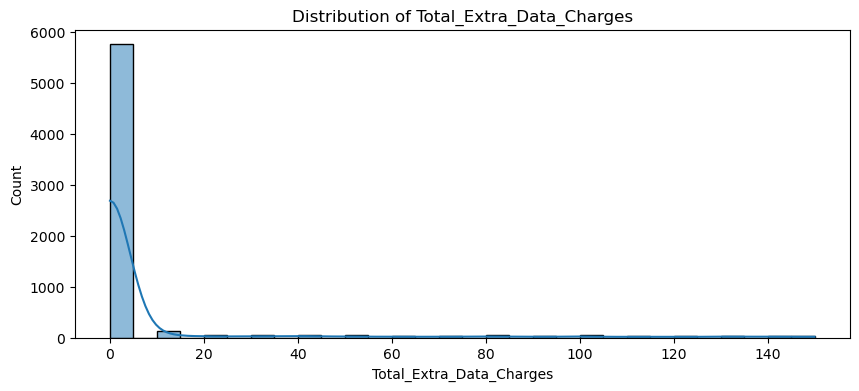

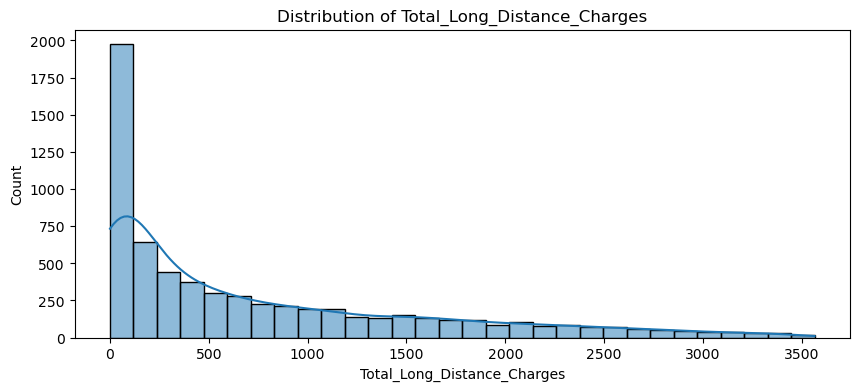

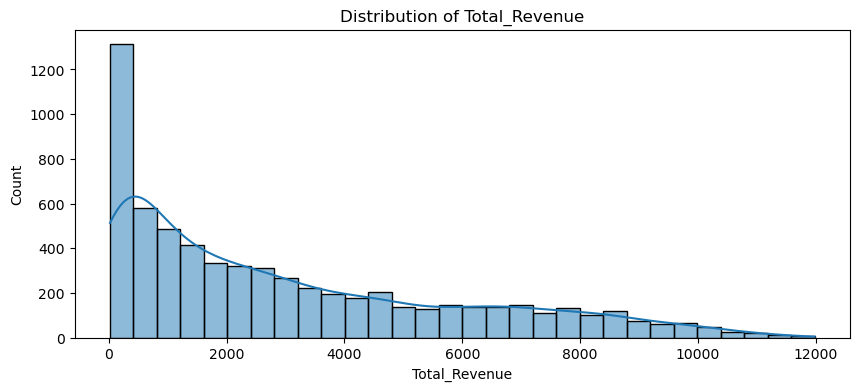

In [90]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

# insight

Age is right-skewed, with most people between 25–60 years and fewer older individuals.

Number_of_Referrals is nearly uniformly distributed across 0–15, showing no strong peaks or skewness.

Tenure: Early churn at 1 month; loyalty improves after 12–24 months.

Monthly Charges: Bimodal — low (~20) vs. high (~80); mid-tier gap.

Total Charges: Right-skewed; few customers drive most revenue.

Refunds: Majority have none; small group shows dissatisfaction or abuse.

Extra Data Charges: Most near zero; heavy users are upsell + churn risk.

Long-Distance & Revenue: Both skewed; minority of high-value customers are critical.

In [107]:
df

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,Male,35,No,Delhi,7,27,Unknown,Yes,No,Yes,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,Unknown,Unknown
1,Female,45,Yes,Maharashtra,14,13,Unknown,Yes,Yes,Yes,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,Unknown,Unknown
2,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,Yes,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,Yes,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,Female,80,No,Tamil Nadu,3,8,Unknown,Yes,No,Yes,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,Female,41,No,Uttar Pradesh,6,33,Unknown,Yes,Yes,Yes,...,Credit Card,74.40,896.75,0.00,0,37.96,934.71,Churned,Competitor,Competitor made better offer
6414,Male,51,Yes,Haryana,0,19,Deal 1,No,Unknown,Yes,...,Credit Card,45.25,3139.80,0.00,0,0.00,3139.80,Stayed,Unknown,Unknown
6415,Female,65,Yes,Kerala,14,25,Unknown,Yes,Yes,Yes,...,Bank Withdrawal,74.95,2869.85,0.00,0,599.64,3469.49,Churned,Dissatisfaction,Product dissatisfaction
6416,Male,23,No,Odisha,2,10,Unknown,Yes,Yes,Yes,...,Credit Card,70.15,4480.70,0.00,0,2107.52,6588.22,Stayed,Unknown,Unknown


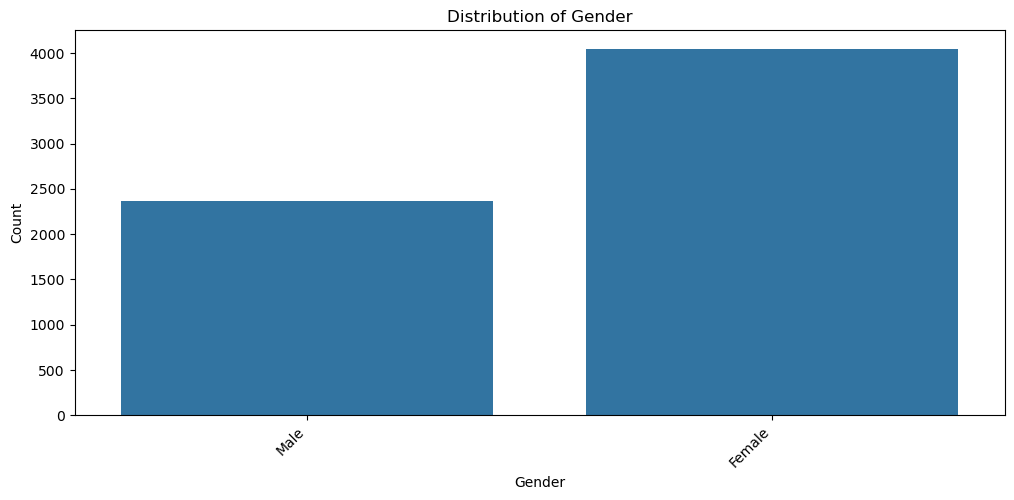

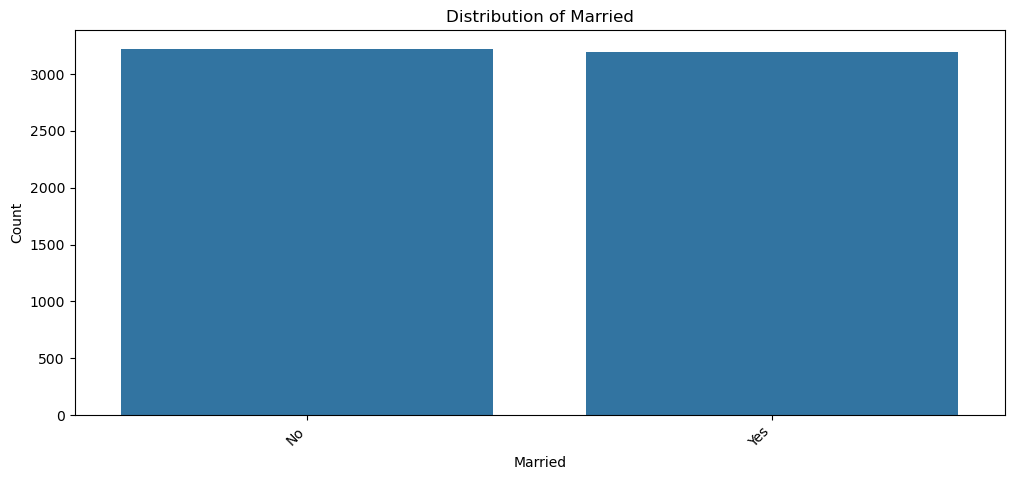

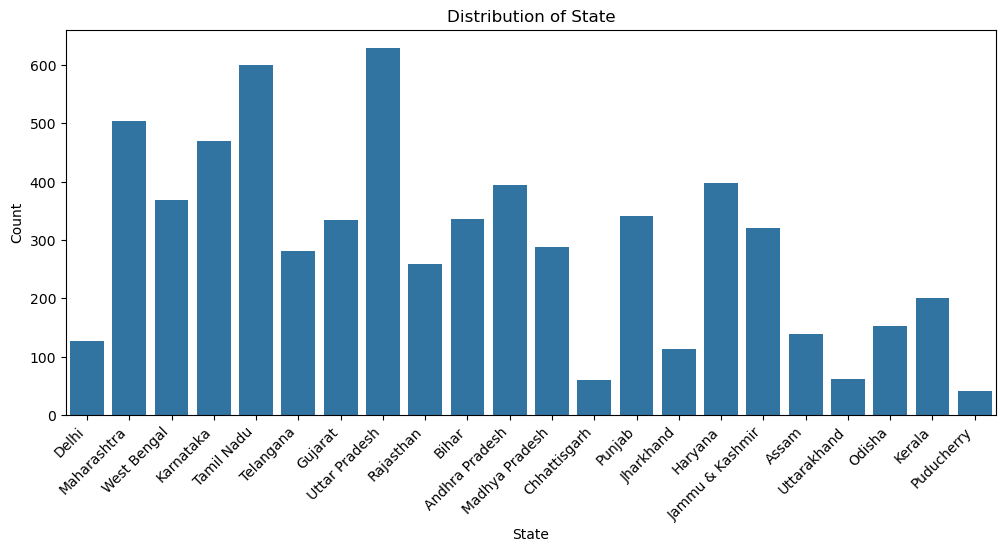

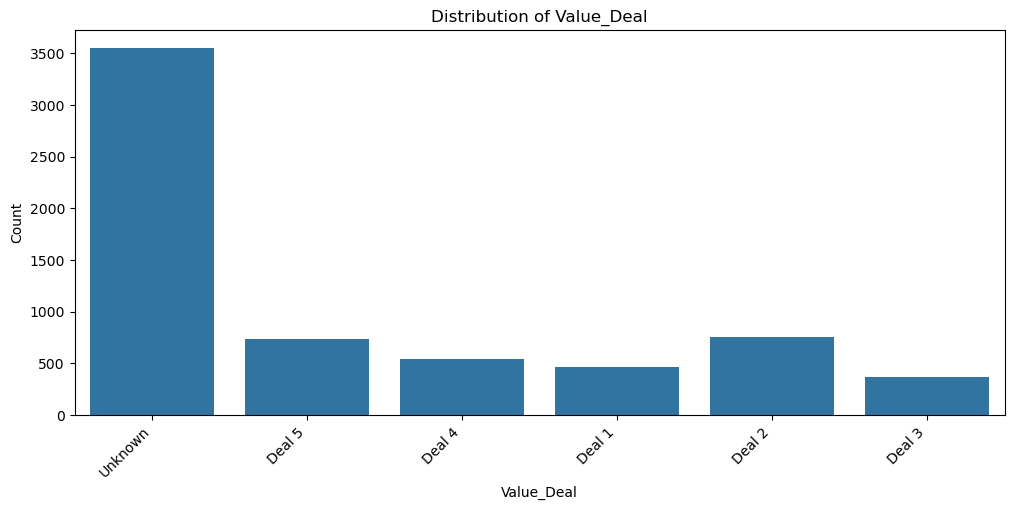

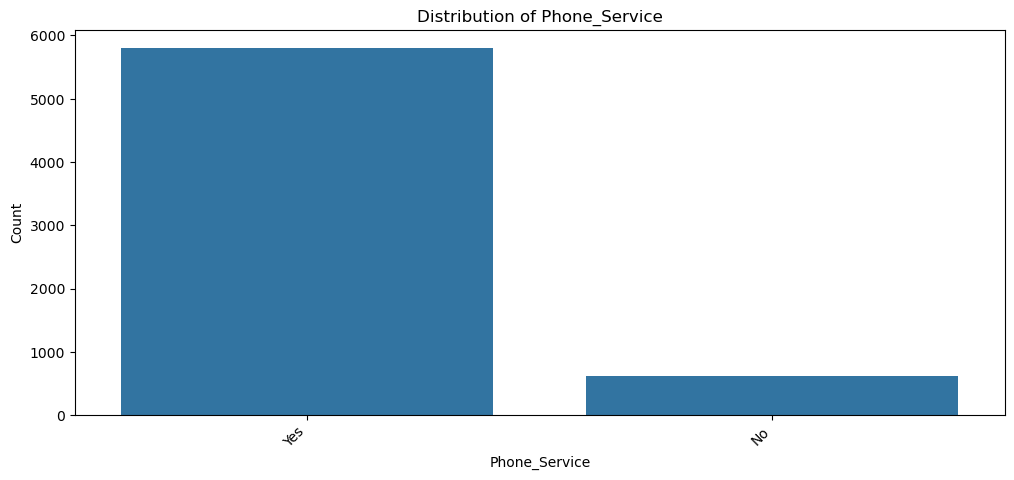

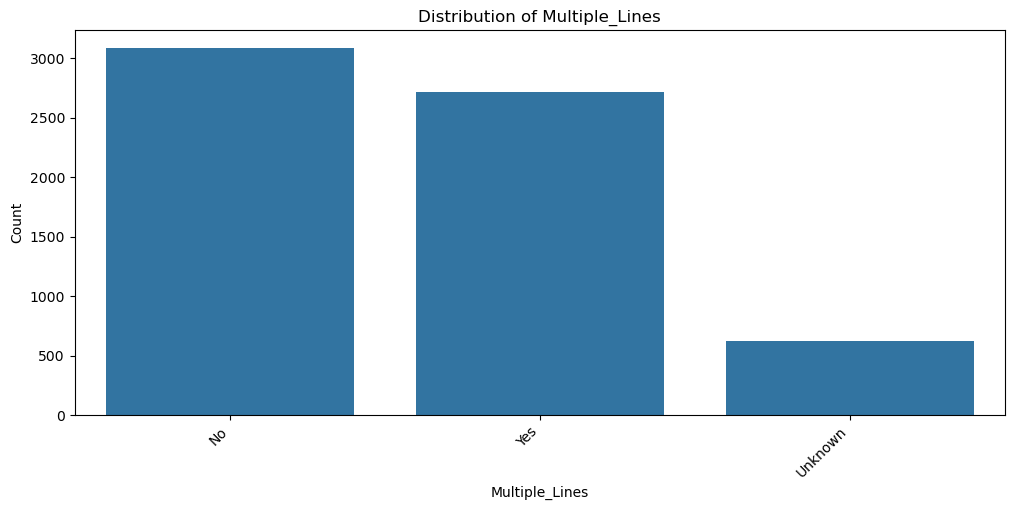

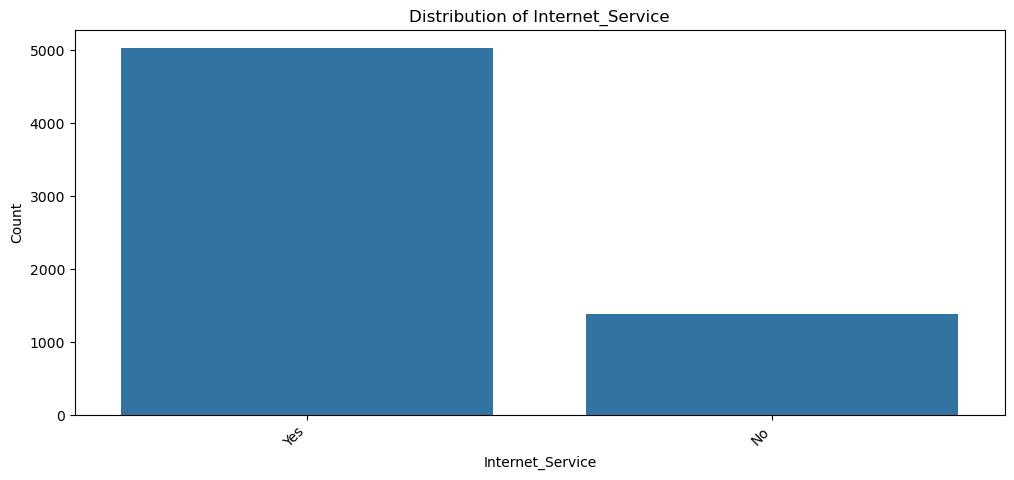

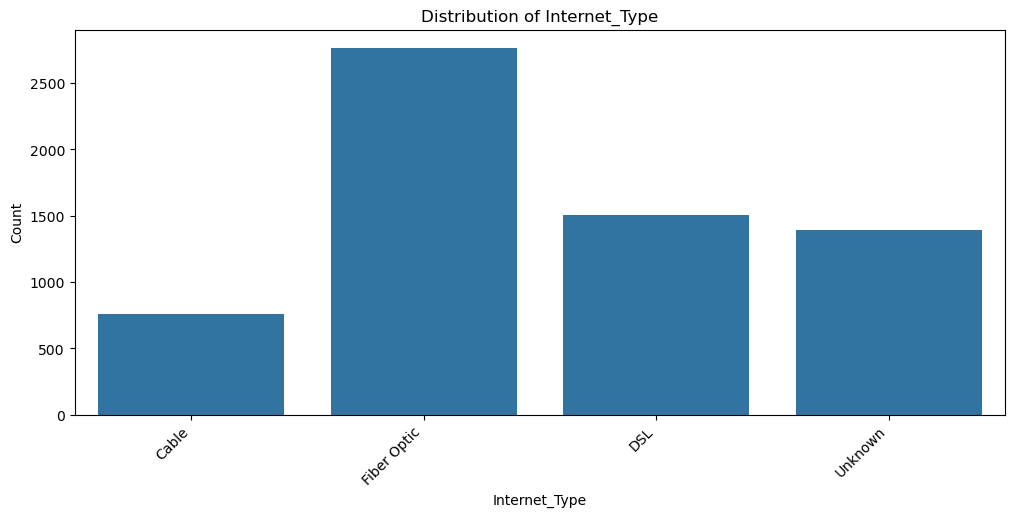

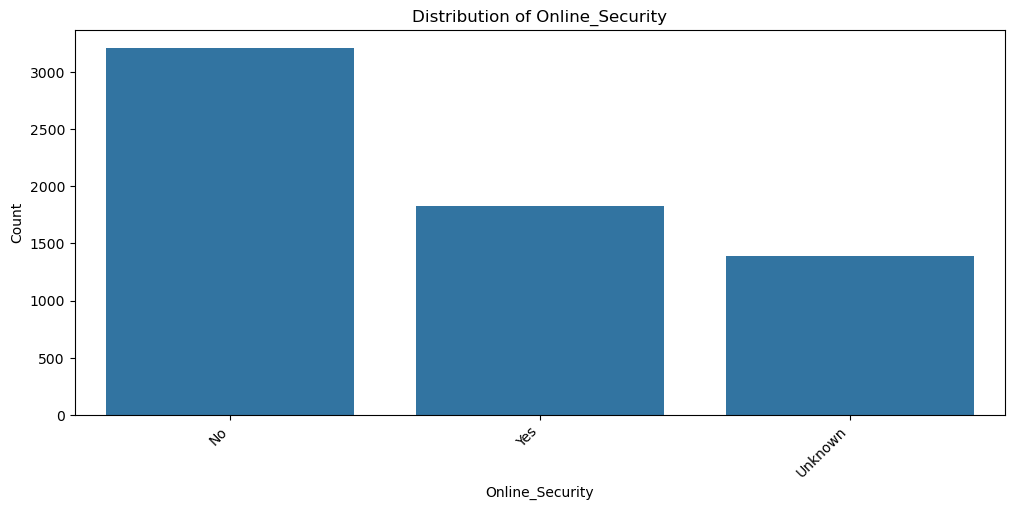

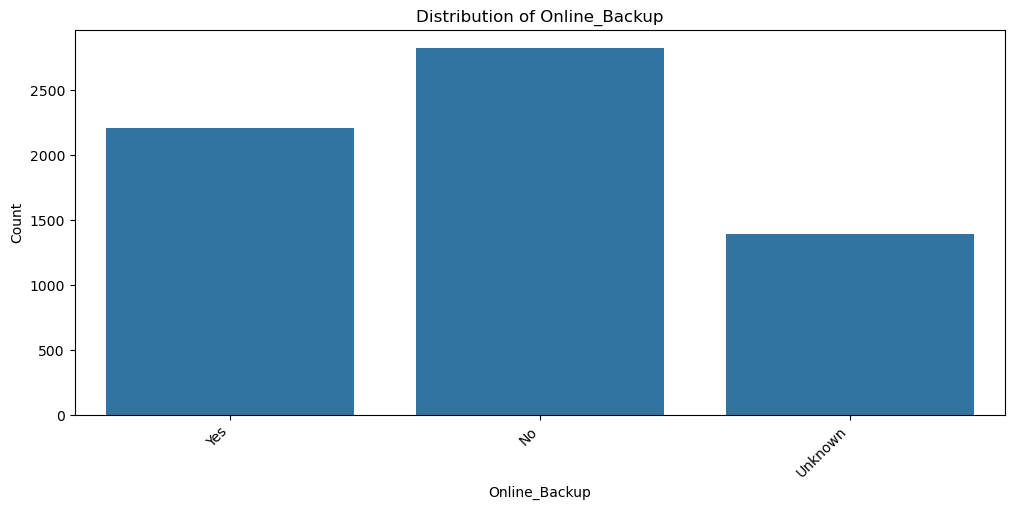

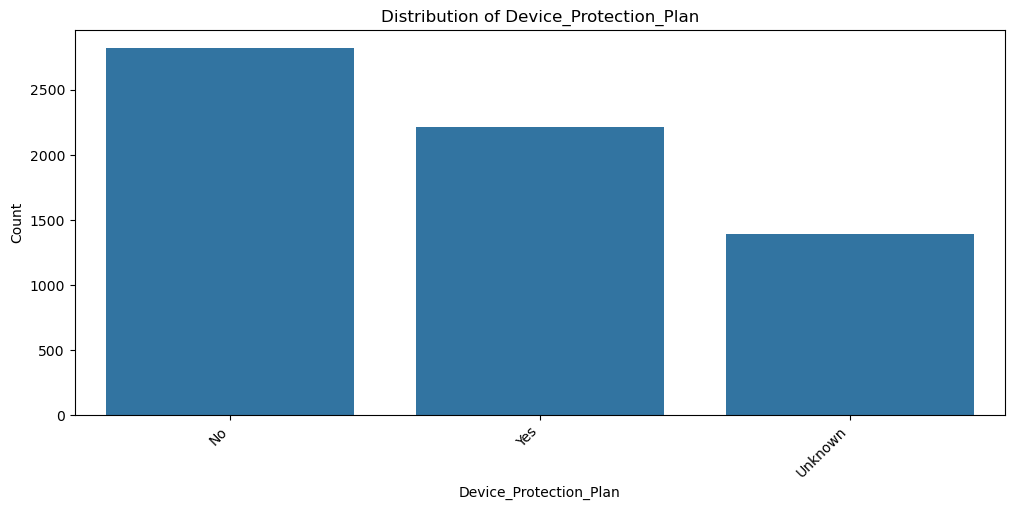

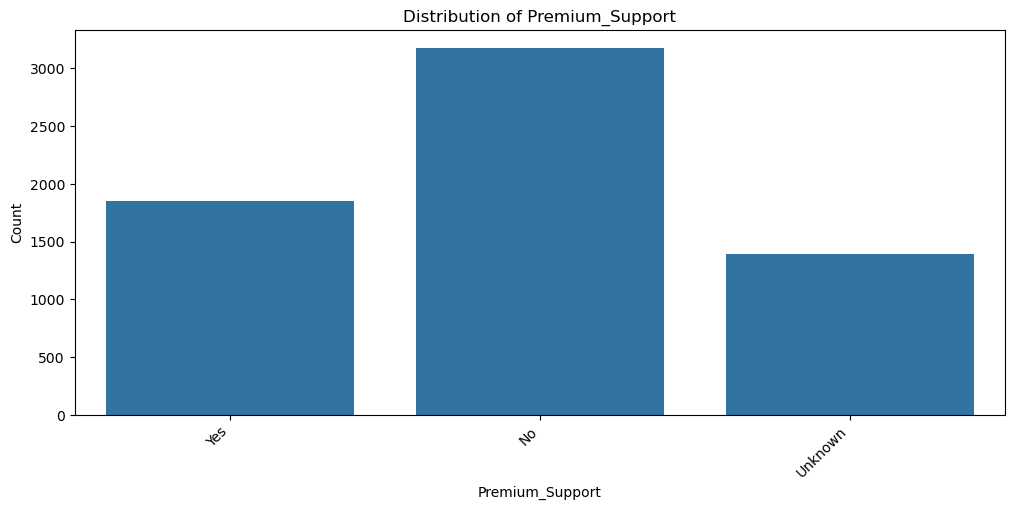

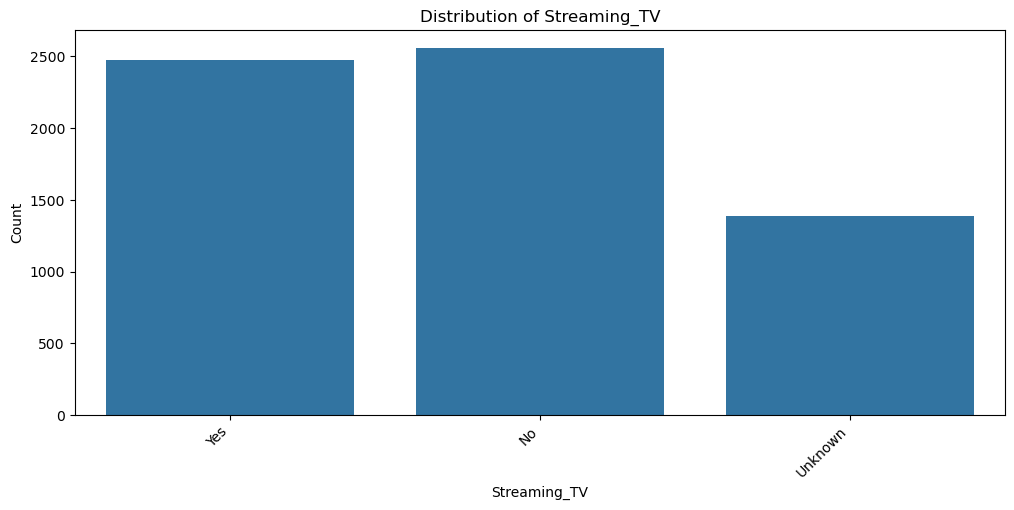

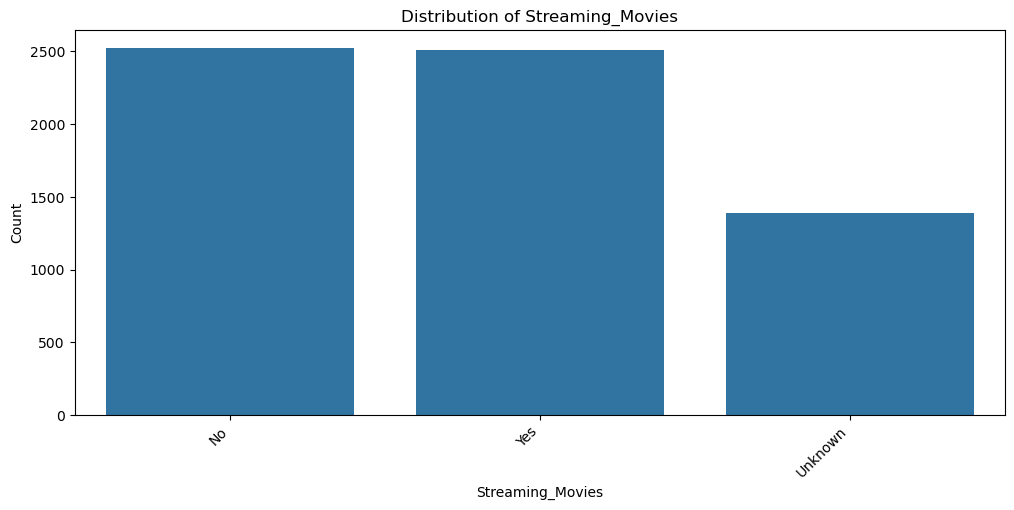

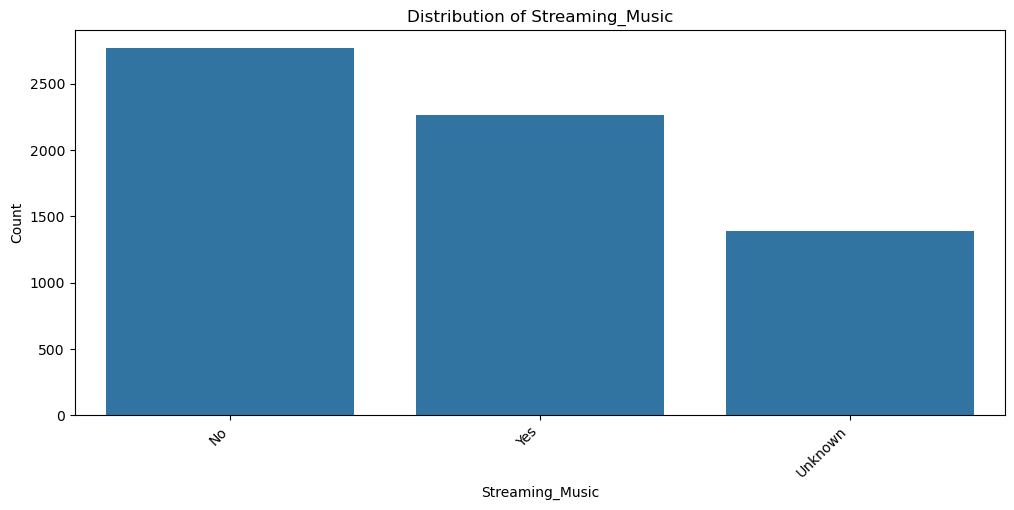

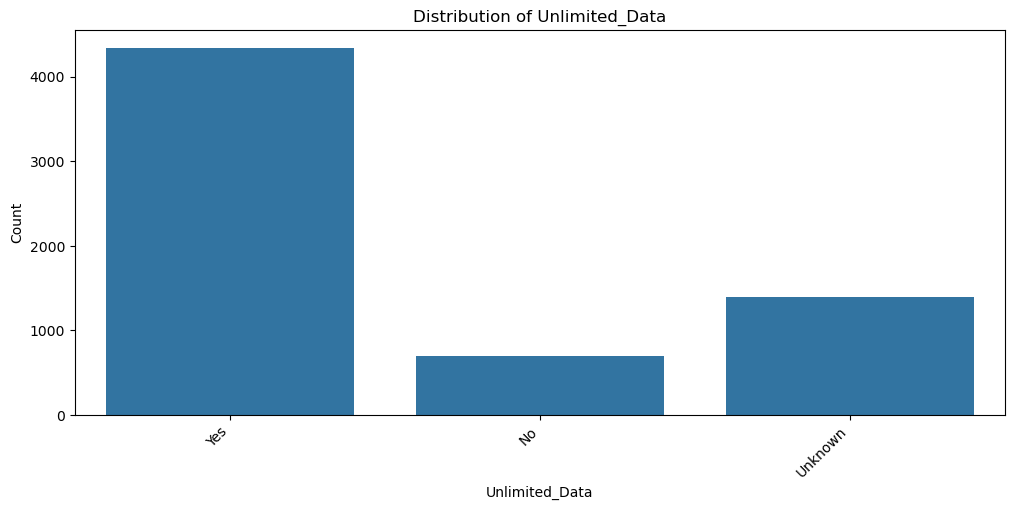

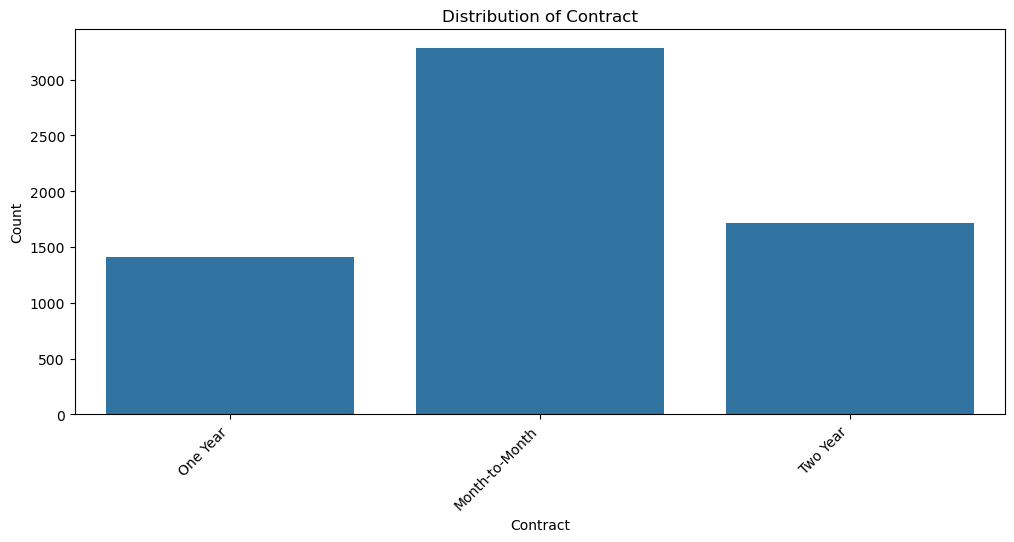

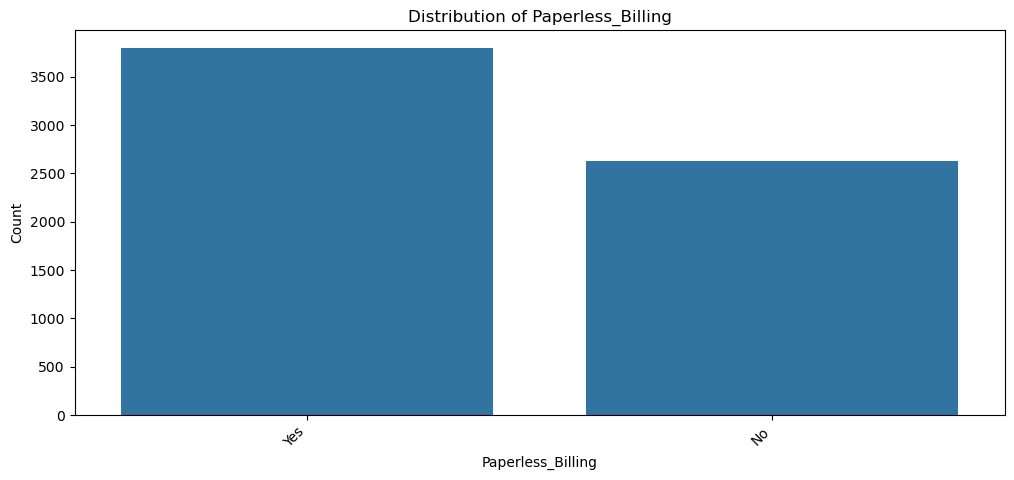

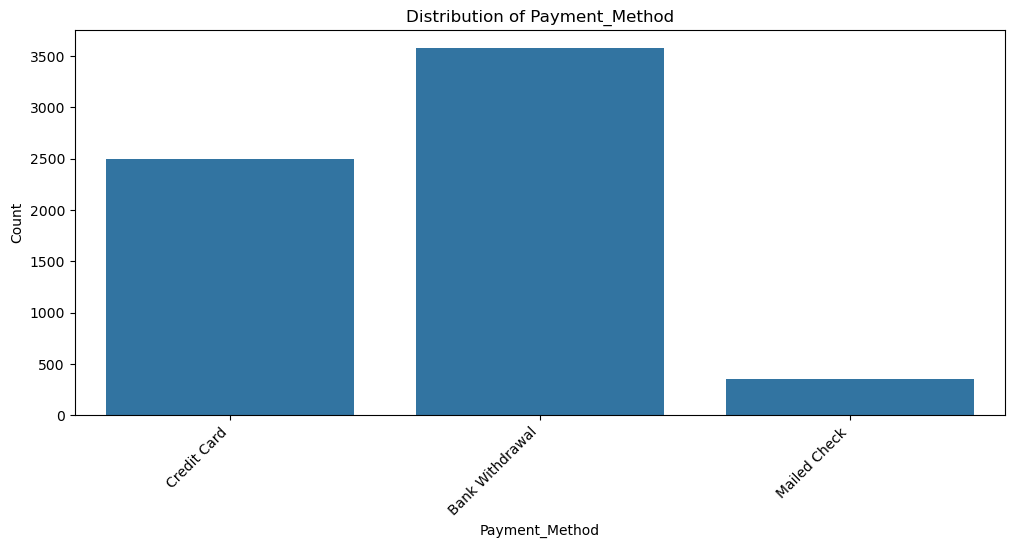

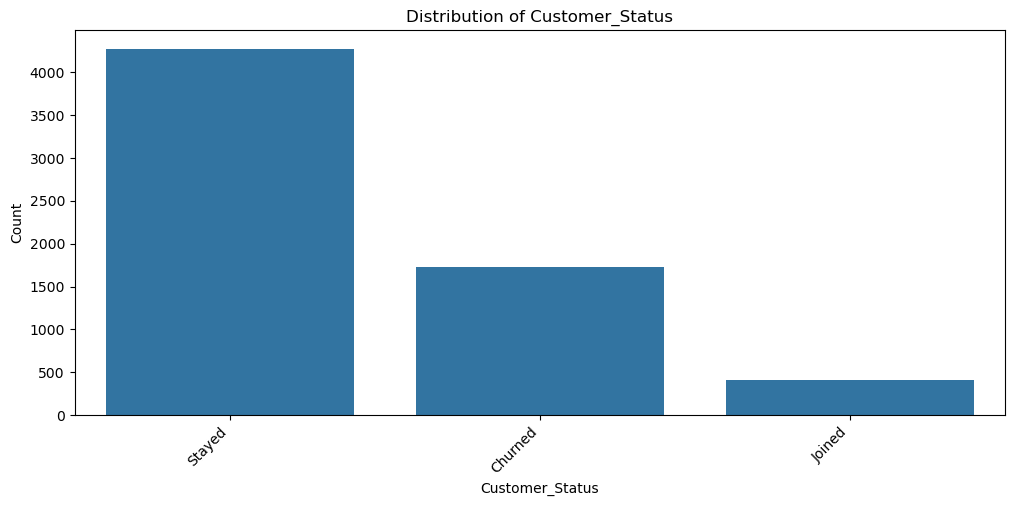

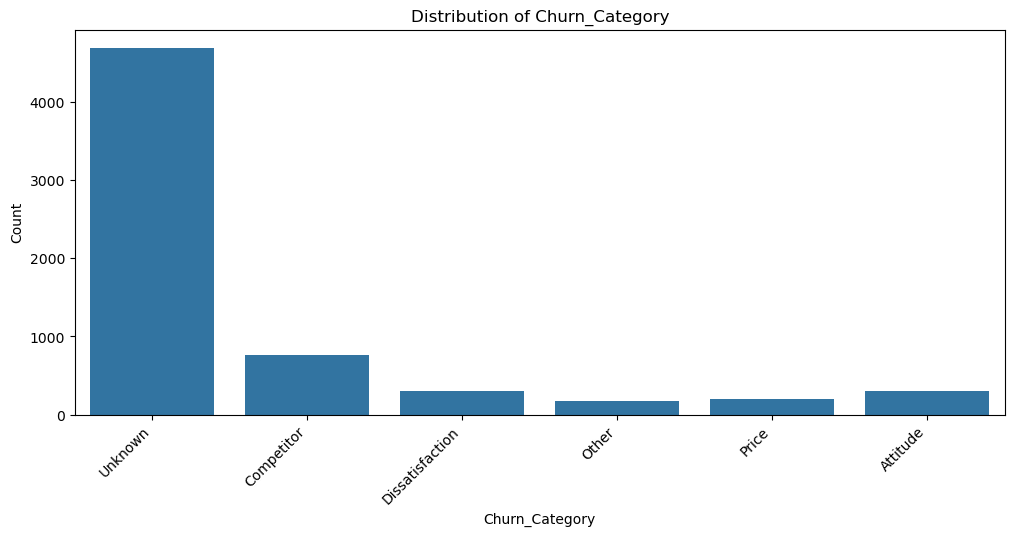

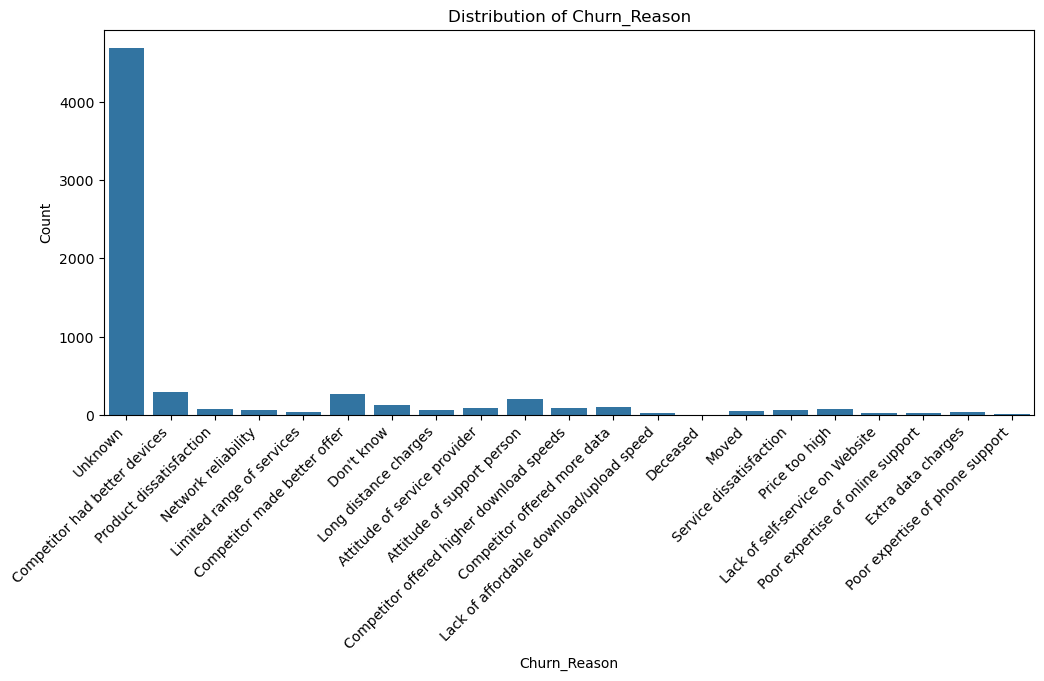

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
    if df[col].dtype == 'object':  # only categorical columns
        plt.figure(figsize=(12,5))
        sns.countplot(x=df[col])  # optional: order by count
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha='right')  # rotate labels to avoid overlap
        plt.title(f"Distribution of {col}")
        plt.show()

# insight 
High‑risk segments:

Female customers

Non‑married customers

Internet service users

Mailed‑check payers

Customers without value deals

High‑charge customers

Retention focus:

Target these high‑risk groups with tailored offers.

Strengthen loyalty among deal‑holders and electronic payment users.

Promote long‑term contracts and improve customer service.

<Axes: xlabel='Customer_Status', ylabel='count'>

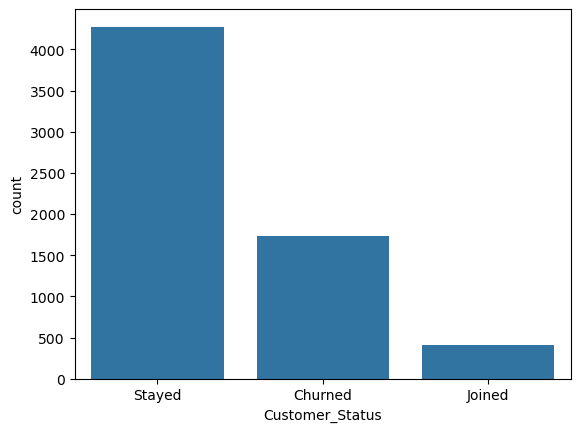

In [92]:
sns.countplot(x='Customer_Status', data=df)

<Axes: xlabel='Gender', ylabel='count'>

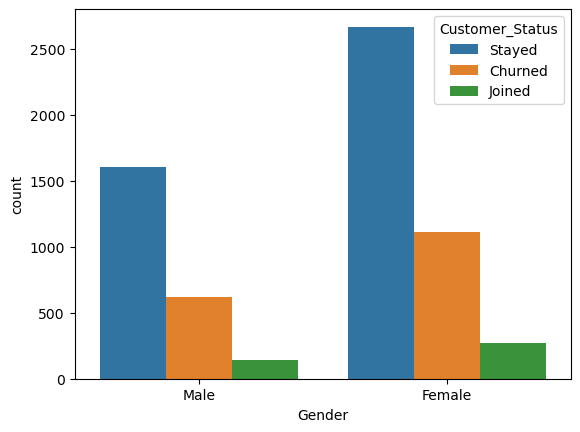

In [93]:
sns.countplot(x='Gender', hue='Customer_Status', data=df)


In [94]:
# female stays long as compare to male and female count is also churn rate high
# female new joinee is also good compare to Male

<Axes: xlabel='Married', ylabel='count'>

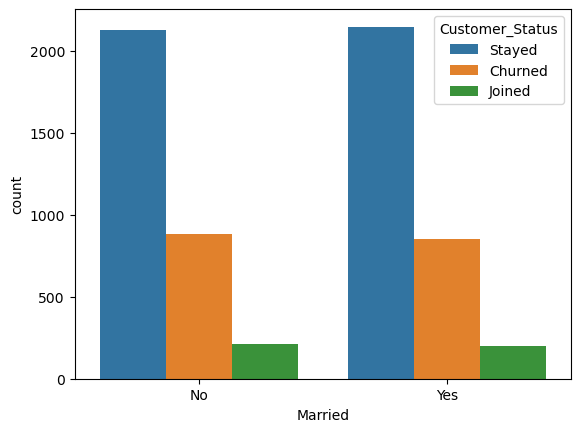

In [95]:
sns.countplot(x='Married', hue='Customer_Status', data=df)


<Axes: xlabel='Phone_Service', ylabel='count'>

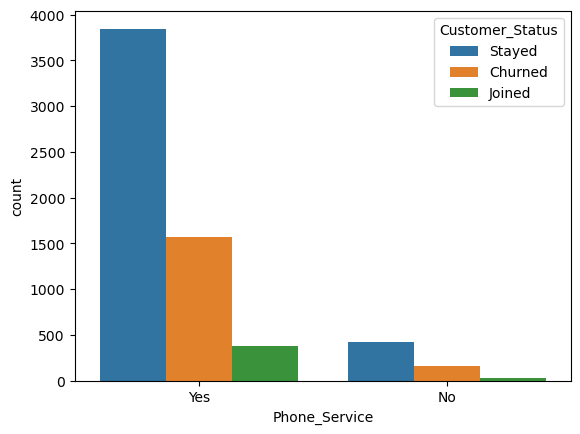

In [96]:
sns.countplot(x='Phone_Service', hue='Customer_Status', data=df)


<Axes: xlabel='Internet_Service', ylabel='count'>

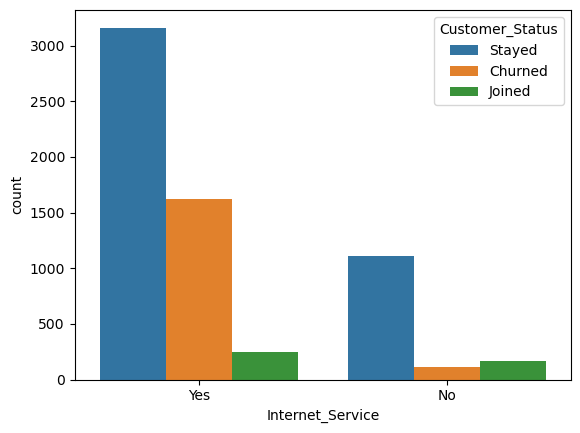

In [97]:
sns.countplot(x='Internet_Service', hue='Customer_Status', data=df)


<Axes: xlabel='Payment_Method', ylabel='count'>

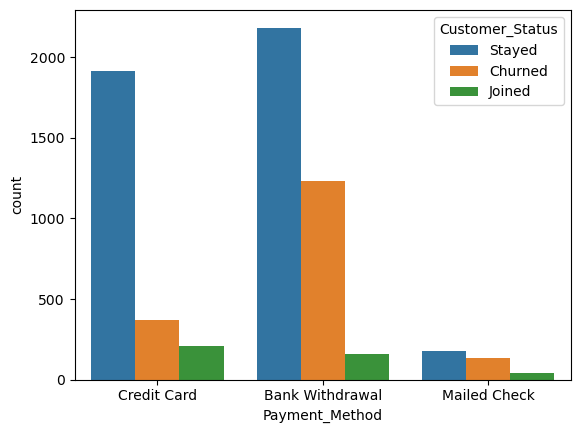

In [98]:
sns.countplot(x='Payment_Method', hue='Customer_Status', data=df)


<Axes: xlabel='Value_Deal', ylabel='count'>

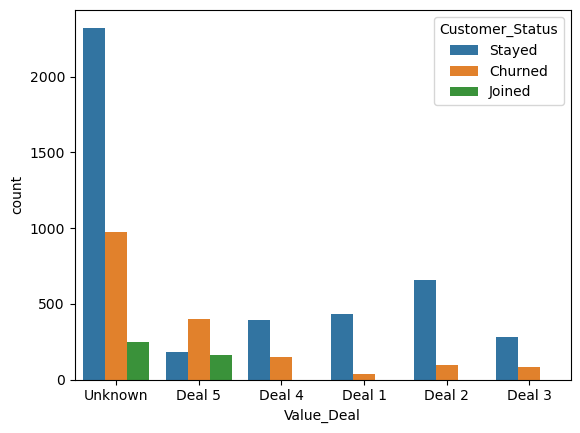

In [99]:
sns.countplot(x='Value_Deal', hue='Customer_Status', data=df)

<Axes: xlabel='Customer_Status', ylabel='Monthly_Charge'>

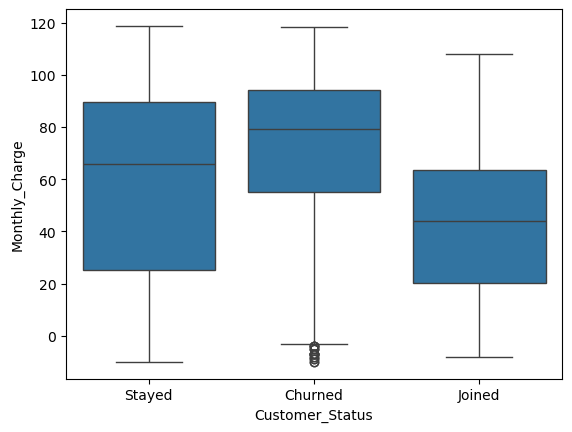

In [100]:
sns.boxplot(x='Customer_Status', y='Monthly_Charge', data=df)

# Insight
- Gender: Females stay longer than males, though female churn count is also high; female new joiners are stronger compared to males.

- Marital Status: Married customers are more stable; non-married churn more.

- Phone Service: Customers with phone service churn more than those without.

- Internet Service: Internet users dominate and show higher churn risk.

- Payment Method: Mailed check users churn more; bank withdrawal/credit card users are steadier.

- Value Deal: Customers with deals churn less; “Unknown” deal group dominates but mostly stayed.
- Monthly Charge vs. Status: Churned customers have the highest median charges, showing price sensitivity.